In [1]:
import pandas as pd

def load_processed_csv(path, id_cols=('InvoiceNo','StockCode','CustomerID')):
    df = pd.read_csv(path)
    for col in id_cols:
        if col in df.columns:
            df[col] = df[col].astype(str)
    return df

valid_purchase_lines = load_processed_csv("../data/processed/valid_purchase_lines.csv")
cancellation_lines = load_processed_csv("../data/processed/cancellation_lines.csv")
cluster_assignments = load_processed_csv("../results/tables/rfm_cluster_assignments.csv")

# Tag each source before combining, so FactSales' cancellation flag is correct
valid_purchase_lines['IsCancellation'] = False
cancellation_lines['IsCancellation'] = True

# Combine into one fact source — both need the same columns
fact_source = pd.concat([valid_purchase_lines, cancellation_lines], ignore_index=True, sort=False)
print(fact_source.shape)
print(fact_source['IsCancellation'].value_counts())

(358454, 15)
IsCancellation
False    349203
True       9251
Name: count, dtype: int64


In [2]:
fact_source['InvoiceDate'] = pd.to_datetime(fact_source['InvoiceDate'])

dim_date = pd.DataFrame({'FullDate': fact_source['InvoiceDate'].dt.normalize().unique()})
dim_date = dim_date.sort_values('FullDate').reset_index(drop=True)
dim_date['DateKey'] = dim_date.index + 1
dim_date['Day'] = dim_date['FullDate'].dt.day
dim_date['Week'] = dim_date['FullDate'].dt.isocalendar().week
dim_date['Month'] = dim_date['FullDate'].dt.month
dim_date['Quarter'] = dim_date['FullDate'].dt.quarter
dim_date['Year'] = dim_date['FullDate'].dt.year

print(dim_date.shape)
dim_date.head()

(305, 7)


,FullDate,DateKey,Day,Week,Month,Quarter,Year
0,2010-12-01,1,1,48,12,4,2010
1,2010-12-02,2,2,48,12,4,2010
2,2010-12-03,3,3,48,12,4,2010
3,2010-12-05,4,5,48,12,4,2010
4,2010-12-06,5,6,49,12,4,2010


In [3]:
dim_product = (
    fact_source.groupby('StockCode')['Description']
    .agg(lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0])
    .reset_index()
)
dim_product['ProductKey'] = dim_product.index + 1
dim_product = dim_product[['ProductKey', 'StockCode', 'Description']]

print(dim_product.shape)
dim_product.head()

(3678, 3)


,ProductKey,StockCode,Description
0,1,10002,INFLATABLE POLITICAL GLOBE
1,2,10080,GROOVY CACTUS INFLATABLE
2,3,10120,DOGGY RUBBER
3,4,10123C,HEARTS WRAPPING TAPE
4,5,10124A,SPOTS ON RED BOOKCOVER TAPE


In [4]:
dim_country = pd.DataFrame({'CountryName': fact_source['Country'].unique()})
dim_country['CountryKey'] = dim_country.index + 1
dim_country = dim_country[['CountryKey', 'CountryName']]

print(dim_country.shape)
dim_country.head()

(30, 2)


,CountryKey,CountryName
0,1,United Kingdom
1,2,Germany
2,3,EIRE
3,4,Italy
4,5,France


In [5]:
dim_customer = fact_source[['CustomerID']].drop_duplicates().reset_index(drop=True)
dim_customer['CustomerKey'] = dim_customer.index + 1

# Attach derived segment (k=5 cluster) where available — not every customer in fact_source
# necessarily has a cluster (e.g., cancellation-only customers who had no valid purchase)
dim_customer = dim_customer.merge(
    cluster_assignments[['CustomerID','Cluster_k5']], on='CustomerID', how='left'
)
dim_customer = dim_customer.rename(columns={'Cluster_k5': 'DerivedSegment'})
dim_customer = dim_customer[['CustomerKey', 'CustomerID', 'DerivedSegment']]

print(dim_customer.shape)
print("Customers with no segment (null):", dim_customer['DerivedSegment'].isna().sum())
dim_customer.head()

(5510, 3)
Customers with no segment (null): 1590


,CustomerKey,CustomerID,DerivedSegment
0,1,17850,0.0
1,2,13047,2.0
2,3,13748,4.0
3,4,15100,4.0
4,5,15291,0.0


In [6]:
def load_processed_csv(path, id_cols=('InvoiceNo','StockCode','CustomerID')):
    df = pd.read_csv(path)
    for col in id_cols:
        if col in df.columns:
            df[col] = df[col].astype(str)
    return df

# All-countries base (for country-level OLAP demos)
all_countries_valid_lines = load_processed_csv("../data/processed/all_countries_valid_purchase_lines.csv")
cancellation_lines = load_processed_csv("../data/processed/cancellation_lines.csv")
cluster_assignments = load_processed_csv("../results/tables/rfm_cluster_assignments.csv")

all_countries_valid_lines['IsCancellation'] = False
cancellation_lines['IsCancellation'] = True

# fact_source_all: broad, for country/revenue breakdowns
fact_source_all = pd.concat([all_countries_valid_lines, cancellation_lines], ignore_index=True, sort=False)
fact_source_all['InvoiceDate'] = pd.to_datetime(fact_source_all['InvoiceDate'])

print("fact_source_all:", fact_source_all.shape)
print(fact_source_all['Country'].nunique(), "countries")
print(fact_source_all['IsCancellation'].value_counts())

fact_source_all: (401943, 15)
38 countries
IsCancellation
False    392692
True       9251
Name: count, dtype: int64


In [7]:
# DimDate
dim_date = pd.DataFrame({'FullDate': fact_source_all['InvoiceDate'].dt.normalize().unique()})
dim_date = dim_date.sort_values('FullDate').reset_index(drop=True)
dim_date['DateKey'] = dim_date.index + 1
dim_date['Day'] = dim_date['FullDate'].dt.day
dim_date['Week'] = dim_date['FullDate'].dt.isocalendar().week
dim_date['Month'] = dim_date['FullDate'].dt.month
dim_date['Quarter'] = dim_date['FullDate'].dt.quarter
dim_date['Year'] = dim_date['FullDate'].dt.year

# DimProduct
dim_product = (
    fact_source_all.groupby('StockCode')['Description']
    .agg(lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0])
    .reset_index()
)
dim_product['ProductKey'] = dim_product.index + 1
dim_product = dim_product[['ProductKey', 'StockCode', 'Description']]

# DimCountry
dim_country = pd.DataFrame({'CountryName': fact_source_all['Country'].unique()})
dim_country['CountryKey'] = dim_country.index + 1
dim_country = dim_country[['CountryKey', 'CountryName']]

# DimCustomer — note DerivedSegment will still be null for non-UK customers,
# since clustering was UK-only by design (matches paper scope). This is expected,
# not an error — document it.
dim_customer = fact_source_all[['CustomerID']].drop_duplicates().reset_index(drop=True)
dim_customer['CustomerKey'] = dim_customer.index + 1
dim_customer = dim_customer.merge(
    cluster_assignments[['CustomerID','Cluster_k5']], on='CustomerID', how='left'
)
dim_customer = dim_customer.rename(columns={'Cluster_k5': 'DerivedSegment'})
dim_customer = dim_customer[['CustomerKey', 'CustomerID', 'DerivedSegment']]

print("DimDate:", dim_date.shape)
print("DimProduct:", dim_product.shape)
print("DimCountry:", dim_country.shape)
print("DimCustomer:", dim_customer.shape, "| null segments:", dim_customer['DerivedSegment'].isna().sum())

DimDate: (305, 7)
DimProduct: (3686, 3)
DimCountry: (38, 2)
DimCustomer: (4372, 3) | null segments: 4372


In [8]:
print("=== fact_source_all / dim_customer CustomerID sample ===")
print(dim_customer['CustomerID'].head(10).tolist())
print(dim_customer['CustomerID'].dtype)

print("\n=== cluster_assignments CustomerID sample ===")
print(cluster_assignments['CustomerID'].head(10).tolist())
print(cluster_assignments['CustomerID'].dtype)

=== fact_source_all / dim_customer CustomerID sample ===
['17850.0', '13047.0', '12583.0', '13748.0', '15100.0', '15291.0', '14688.0', '17809.0', '15311.0', '16098.0']
object

=== cluster_assignments CustomerID sample ===
['12346', '12747', '12748', '12749', '12820', '12821', '12822', '12823', '12824', '12826']
object


In [9]:
def clean_customer_id(series):
    return series.astype(str).str.replace(r'\.0$', '', regex=True)

all_countries_valid_lines['CustomerID'] = clean_customer_id(all_countries_valid_lines['CustomerID'])
cancellation_lines['CustomerID'] = clean_customer_id(cancellation_lines['CustomerID'])
cluster_assignments['CustomerID'] = clean_customer_id(cluster_assignments['CustomerID'])

# rebuild fact_source_all with cleaned IDs
fact_source_all = pd.concat([all_countries_valid_lines, cancellation_lines], ignore_index=True, sort=False)
fact_source_all['InvoiceDate'] = pd.to_datetime(fact_source_all['InvoiceDate'])

# rebuild dim_customer
dim_customer = fact_source_all[['CustomerID']].drop_duplicates().reset_index(drop=True)
dim_customer['CustomerKey'] = dim_customer.index + 1
dim_customer = dim_customer.merge(
    cluster_assignments[['CustomerID','Cluster_k5']], on='CustomerID', how='left'
)
dim_customer = dim_customer.rename(columns={'Cluster_k5': 'DerivedSegment'})
dim_customer = dim_customer[['CustomerKey', 'CustomerID', 'DerivedSegment']]

print("DimCustomer:", dim_customer.shape, "| null segments:", dim_customer['DerivedSegment'].isna().sum())

DimCustomer: (4372, 3) | null segments: 452


## DimCustomer.DerivedSegment - confirmed null count

4,372 total unique customers in DimCustomer (matches raw data quality report's "unique customers known" count exactly). 3,920 have a DerivedSegment (matches customer_features_rfm row count exactly, from Section 18's UK-only RFM baseline). The remaining 452 are customers whose valid purchases were entirely non-UK, correctly excluded from RFM clustering per the baseline's UK-only scope. Verified as fully explained by cross-referencing three independently-computed counts across different notebooks - not a data quality defect.

In [10]:
fact_sales = fact_source_all.copy()
fact_sales['InvoiceDate_norm'] = fact_sales['InvoiceDate'].dt.normalize()

fact_sales = fact_sales.merge(dim_date[['FullDate','DateKey']], left_on='InvoiceDate_norm', right_on='FullDate', how='left')
fact_sales = fact_sales.merge(dim_product[['StockCode','ProductKey']], on='StockCode', how='left')
fact_sales = fact_sales.merge(dim_customer[['CustomerID','CustomerKey']], on='CustomerID', how='left')
fact_sales = fact_sales.merge(dim_country.rename(columns={'CountryName':'Country'}), on='Country', how='left')

fact_sales['Revenue'] = fact_sales['Quantity'] * fact_sales['UnitPrice']

FactSales = fact_sales[[
    'InvoiceNo', 'ProductKey', 'CustomerKey', 'DateKey', 'CountryKey',
    'Quantity', 'UnitPrice', 'Revenue', 'IsCancellation'
]].copy()

print(FactSales.shape)
print("Any null keys?", FactSales[['ProductKey','CustomerKey','DateKey','CountryKey']].isna().any().any())
FactSales.head()

(401943, 9)
Any null keys? False


,InvoiceNo,ProductKey,CustomerKey,DateKey,CountryKey,Quantity,UnitPrice,Revenue,IsCancellation
0,536365,3250,1,1,1,6,2.55,15.30,False
1,536365,2650,1,1,1,6,3.39,20.34,False
2,536365,2856,1,1,1,8,2.75,22.00,False
3,536365,2804,1,1,1,6,3.39,20.34,False
4,536365,2803,1,1,1,6,3.39,20.34,False


In [11]:
import duckdb

con = duckdb.connect(database=':memory:')

con.register('FactSales', FactSales)
con.register('DimDate', dim_date)
con.register('DimProduct', dim_product)
con.register('DimCustomer', dim_customer)
con.register('DimCountry', dim_country)

# sanity check
print(con.execute("SELECT COUNT(*) FROM FactSales").fetchdf())

   count_star()
0        401943


In [12]:
q1 = con.execute("""
    SELECT 
        d.Year, d.Month,
        SUM(CASE WHEN f.IsCancellation = false THEN f.Revenue ELSE 0 END) AS GrossRevenue,
        SUM(CASE WHEN f.IsCancellation = true THEN f.Revenue ELSE 0 END) AS CancelledRevenue,
        COUNT(DISTINCT f.InvoiceNo) AS InvoiceCount
    FROM FactSales f
    JOIN DimDate d ON f.DateKey = d.DateKey
    GROUP BY d.Year, d.Month
    ORDER BY d.Year, d.Month
""").fetchdf()
print(q1)

    Year  Month  GrossRevenue  CancelledRevenue  InvoiceCount
0   2010     12    570422.730         -74729.12          1726
1   2011      1    568101.310        -131363.05          1247
2   2011      2    446084.920         -25519.15          1216
3   2011      3    594081.760         -34201.28          1639
4   2011      4    468374.331         -44600.65          1389
5   2011      5    677355.150         -47202.51          1869
6   2011      6    660046.050         -70569.78          1722
7   2011      7    598962.901         -37919.13          1601
8   2011      8    644051.040         -54330.80          1558
9   2011      9    950690.202         -38838.51          2088
10  2011     10   1035642.450         -81895.50          2291
11  2011     11   1156205.610         -47720.98          3098
12  2011     12    517190.440        -205089.27           924


In [13]:
dec_2011_cancellations = con.execute("""
    SELECT f.InvoiceNo, f.CustomerKey, f.Revenue, f.Quantity, p.Description
    FROM FactSales f
    JOIN DimDate d ON f.DateKey = d.DateKey
    JOIN DimProduct p ON f.ProductKey = p.ProductKey
    WHERE d.Year = 2011 AND d.Month = 12 AND f.IsCancellation = true
    ORDER BY f.Revenue ASC
    LIMIT 10
""").fetchdf()
print(dec_2011_cancellations)

  InvoiceNo  CustomerKey    Revenue  Quantity  \
0   C581484         2605 -168469.60    -80995   
1   C580605         4344  -17836.46        -1   
2   C580604         4344  -11586.50        -1   
3   C580726         3309   -1100.44        -1   
4   C580971          698    -637.50      -250   
5   C580702          702    -238.00       -40   
6   C581499          457    -224.69        -1   
7   C581228          595    -162.00       -24   
8   C581009         3985    -125.00        -1   
9   C580954          191     -93.75       -25   

                           Description  
0          PAPER CRAFT , LITTLE BIRDIE  
1                           AMAZON FEE  
2                           AMAZON FEE  
3                      CRUK Commission  
4               OFFICE MUG WARMER PINK  
5     VINTAGE DOILY DELUXE SEWING KIT   
6                               Manual  
7                GUMBALL MAGAZINE RACK  
8                               Manual  
9  SET3 BOOK BOX GREEN GINGHAM FLOWER   


In [14]:
q2 = con.execute("""
    SELECT 
        c.CountryName,
        SUM(CASE WHEN f.IsCancellation = false THEN f.Revenue ELSE 0 END) AS GrossRevenue,
        COUNT(DISTINCT f.InvoiceNo) AS InvoiceCount,
        COUNT(DISTINCT f.CustomerKey) AS CustomerCount
    FROM FactSales f
    JOIN DimCountry c ON f.CountryKey = c.CountryKey
    GROUP BY c.CountryName
    ORDER BY GrossRevenue DESC
    LIMIT 15
""").fetchdf()
print(q2)

       CountryName  GrossRevenue  InvoiceCount  CustomerCount
0   United Kingdom  7.285025e+06         20018           3950
1      Netherlands  2.854463e+05           100              9
2             EIRE  2.652625e+05           332              4
3          Germany  2.286784e+05           603             95
4           France  2.089343e+05           458             87
5        Australia  1.384538e+05            69              9
6            Spain  6.155856e+04           105             31
7      Switzerland  5.644395e+04            71             21
8          Belgium  4.119634e+04           119             25
9           Sweden  3.836783e+04            46              8
10           Japan  3.741637e+04            28              8
11          Norway  3.616544e+04            40             10
12        Portugal  3.337584e+04            70             19
13         Finland  2.254608e+04            48             12
14       Singapore  2.127929e+04            10              1


## OLAP Cross-Validation: December 2011 Cancellation Spike (Output 1)

December 2011's cancellation total (-£205,089) is dominated by a single invoice, C581484 (-£168,470), which is the exact cancellation/reversal of invoice 541431... 581483 - the same "PAPER CRAFT, LITTLE BIRDIE" data-entry error (80,995 units) independently flagged and confirmed via N0 anomaly detection (Section 23). The merchant's own system reversing this transaction is corroborating evidence the N0 verdict (probable data entry error) was correct. Excluding this one invoice, December's cancellation total would be roughly -£36,600 - much more in line with other months (e.g., November: -£47,721), confirming the raw December figure is dominated by this one anomaly rather than reflecting a genuine cancellation-rate trend.

In [15]:
q3_revenue = con.execute("""
    SELECT p.StockCode, p.Description, 
           SUM(f.Revenue) AS TotalRevenue,
           SUM(f.Quantity) AS TotalQuantity
    FROM FactSales f
    JOIN DimProduct p ON f.ProductKey = p.ProductKey
    WHERE f.IsCancellation = false
    GROUP BY p.StockCode, p.Description
    ORDER BY TotalRevenue DESC
    LIMIT 10
""").fetchdf()
print("=== Top 10 by Revenue ===")
print(q3_revenue)

q3_quantity = con.execute("""
    SELECT p.StockCode, p.Description, 
           SUM(f.Quantity) AS TotalQuantity,
           SUM(f.Revenue) AS TotalRevenue
    FROM FactSales f
    JOIN DimProduct p ON f.ProductKey = p.ProductKey
    WHERE f.IsCancellation = false
    GROUP BY p.StockCode, p.Description
    ORDER BY TotalQuantity DESC
    LIMIT 10
""").fetchdf()
print("\n=== Top 10 by Quantity ===")
print(q3_quantity)

=== Top 10 by Revenue ===
  StockCode                         Description  TotalRevenue  TotalQuantity
0     23843         PAPER CRAFT , LITTLE BIRDIE     168469.60        80995.0
1     22423            REGENCY CAKESTAND 3 TIER     142264.75        12374.0
2    85123A  WHITE HANGING HEART T-LIGHT HOLDER     100547.45        36763.0
3    85099B             JUMBO BAG RED RETROSPOT      85040.54        46078.0
4     23166      MEDIUM CERAMIC TOP STORAGE JAR      81416.73        77916.0
5      POST                             POSTAGE      77803.96         3120.0
6     47566                       PARTY BUNTING      68785.23        15279.0
7     84879       ASSORTED COLOUR BIRD ORNAMENT      56413.03        35263.0
8         M                              Manual      53419.93         6933.0
9     23084                  RABBIT NIGHT LIGHT      51251.24        27153.0

=== Top 10 by Quantity ===
  StockCode                         Description  TotalQuantity  TotalRevenue
0     23843         PA

In [16]:
ADMIN_CODES = ['BANK CHARGES', 'C2', 'DOT', 'M', 'POST']
LIKELY_ERROR_INVOICES = ['541431', '581483']

q3_revenue_clean = con.execute(f"""
    SELECT p.StockCode, p.Description, 
           SUM(f.Revenue) AS TotalRevenue,
           SUM(f.Quantity) AS TotalQuantity
    FROM FactSales f
    JOIN DimProduct p ON f.ProductKey = p.ProductKey
    WHERE f.IsCancellation = false
      AND p.StockCode NOT IN ({','.join([repr(c) for c in ADMIN_CODES])})
      AND f.InvoiceNo NOT IN ({','.join([repr(i) for i in LIKELY_ERROR_INVOICES])})
    GROUP BY p.StockCode, p.Description
    ORDER BY TotalRevenue DESC
    LIMIT 10
""").fetchdf()
print("=== Top 10 by Revenue (excluding admin codes + known data errors) ===")
print(q3_revenue_clean)

q3_quantity_clean = con.execute(f"""
    SELECT p.StockCode, p.Description, 
           SUM(f.Quantity) AS TotalQuantity,
           SUM(f.Revenue) AS TotalRevenue
    FROM FactSales f
    JOIN DimProduct p ON f.ProductKey = p.ProductKey
    WHERE f.IsCancellation = false
      AND p.StockCode NOT IN ({','.join([repr(c) for c in ADMIN_CODES])})
      AND f.InvoiceNo NOT IN ({','.join([repr(i) for i in LIKELY_ERROR_INVOICES])})
    GROUP BY p.StockCode, p.Description
    ORDER BY TotalQuantity DESC
    LIMIT 10
""").fetchdf()
print("\n=== Top 10 by Quantity (excluding admin codes + known data errors) ===")
print(q3_quantity_clean)

=== Top 10 by Revenue (excluding admin codes + known data errors) ===
  StockCode                         Description  TotalRevenue  TotalQuantity
0     22423            REGENCY CAKESTAND 3 TIER     142264.75        12374.0
1    85123A  WHITE HANGING HEART T-LIGHT HOLDER     100547.45        36763.0
2    85099B             JUMBO BAG RED RETROSPOT      85040.54        46078.0
3     47566                       PARTY BUNTING      68785.23        15279.0
4     84879       ASSORTED COLOUR BIRD ORNAMENT      56413.03        35263.0
5     23084                  RABBIT NIGHT LIGHT      51251.24        27153.0
6     22502          PICNIC BASKET WICKER SMALL      47348.35         1485.0
7     79321                       CHILLI LIGHTS      46265.11         9646.0
8     22086     PAPER CHAIN KIT 50'S CHRISTMAS       42584.13        15591.0
9     21137            BLACK RECORD COVER FRAME      39045.80        11401.0

=== Top 10 by Quantity (excluding admin codes + known data errors) ===
  StockCode

## Output 3: Top Products - Raw vs. Cleaned

Raw top-10 rankings are distorted by the two confirmed data-entry errors (Section 23) and administrative charge codes (postage, manual adjustments) appearing alongside genuine products. Cleaned version excludes `InvoiceNo` 541431/581483 and admin StockCodes {BANK CHARGES, C2, DOT, M, POST}, giving a merchandising-accurate top-products view.

In [17]:
q4 = con.execute("""
    SELECT 
        d.Year, d.Month, 
        c.DerivedSegment,
        COUNT(DISTINCT f.InvoiceNo) AS InvoiceCount,
        SUM(CASE WHEN f.IsCancellation = false THEN f.Revenue ELSE 0 END) AS Revenue,
        COUNT(DISTINCT f.CustomerKey) AS ActiveCustomers
    FROM FactSales f
    JOIN DimDate d ON f.DateKey = d.DateKey
    JOIN DimCustomer c ON f.CustomerKey = c.CustomerKey
    WHERE c.DerivedSegment IS NOT NULL
    GROUP BY d.Year, d.Month, c.DerivedSegment
    ORDER BY d.Year, d.Month, c.DerivedSegment
""").fetchdf()
print(q4.head(20))
print("\nTotal rows:", len(q4))

    Year  Month  DerivedSegment  InvoiceCount    Revenue  ActiveCustomers
0   2010     12             0.0           661  285919.09              221
1   2010     12             1.0            54    8378.46               48
2   2010     12             2.0           373   91040.68              242
3   2010     12             3.0           182   32889.59              156
4   2010     12             4.0           285   78249.52              187
5   2011      1             0.0           465  183643.91              203
6   2011      1             1.0            22    2670.71               20
7   2011      1             2.0           261   70457.93              198
8   2011      1             3.0           113   20747.75               97
9   2011      1             4.0           228  163356.03              165
10  2011      2             0.0           423  181163.82              192
11  2011      2             1.0            28    4277.32               25
12  2011      2             2.0       

In [18]:
q5_country = con.execute("""
    SELECT 
        c.CountryName,
        COUNT(DISTINCT CASE WHEN f.IsCancellation = true THEN f.InvoiceNo END) AS CancelledInvoices,
        COUNT(DISTINCT f.InvoiceNo) AS TotalInvoices,
        ROUND(100.0 * COUNT(DISTINCT CASE WHEN f.IsCancellation = true THEN f.InvoiceNo END) 
              / COUNT(DISTINCT f.InvoiceNo), 2) AS CancellationRatePct
    FROM FactSales f
    JOIN DimCountry c ON f.CountryKey = c.CountryKey
    GROUP BY c.CountryName
    HAVING COUNT(DISTINCT f.InvoiceNo) >= 20  -- avoid noisy rates from tiny-volume countries
    ORDER BY CancellationRatePct DESC
    LIMIT 15
""").fetchdf()
print("=== Cancellation rate by country ===")
print(q5_country)

q5_segment = con.execute("""
    SELECT 
        c.DerivedSegment,
        COUNT(DISTINCT CASE WHEN f.IsCancellation = true THEN f.InvoiceNo END) AS CancelledInvoices,
        COUNT(DISTINCT f.InvoiceNo) AS TotalInvoices,
        ROUND(100.0 * COUNT(DISTINCT CASE WHEN f.IsCancellation = true THEN f.InvoiceNo END) 
              / COUNT(DISTINCT f.InvoiceNo), 2) AS CancellationRatePct
    FROM FactSales f
    JOIN DimCustomer c ON f.CustomerKey = c.CustomerKey
    WHERE c.DerivedSegment IS NOT NULL
    GROUP BY c.DerivedSegment
    ORDER BY c.DerivedSegment
""").fetchdf()
print("\n=== Cancellation rate by segment ===")
print(q5_segment)

=== Cancellation rate by country ===
        CountryName  CancelledInvoices  TotalInvoices  CancellationRatePct
0             Japan                  9             28                32.14
1             Italy                 17             55                30.91
2       Switzerland                 20             71                28.17
3           Germany                146            603                24.21
4            Sweden                 10             46                21.74
5              EIRE                 72            332                21.69
6   Channel Islands                  7             33                21.21
7            Poland                  5             24                20.83
8            Cyprus                  4             20                20.00
9          Portugal                 13             70                18.57
10          Belgium                 21            119                17.65
11        Australia                 12             69          

## Output 5: Cancellation Rate by Segment - Interpretation Caveat

Segment 0 (highest-value, highest-frequency) shows the highest cancellation rate (17.57%) and Segment 1 (lowest-frequency) the lowest (8.95%). This likely reflects invoice volume rather than a genuine behavioral difference: Segment 0 places 7,598 invoices vs. Segment 1's 1,396, so even an identical per-order cancellation probability would produce more total cancellations, and a higher rate is plausible simply from more purchase attempts (e.g., ordering slightly wrong items more often due to higher overall activity). This is a descriptive OLAP finding, not a causal claim - establishing true behavioral difference would require controlling for order volume, which is outside this module's scope.

In [19]:
# --- Roll-up: Daily -> Weekly -> Monthly revenue ---
rollup_daily = con.execute("""
    SELECT d.FullDate, SUM(f.Revenue) AS Revenue
    FROM FactSales f JOIN DimDate d ON f.DateKey = d.DateKey
    WHERE f.IsCancellation = false
    GROUP BY d.FullDate ORDER BY d.FullDate LIMIT 5
""").fetchdf()

rollup_weekly = con.execute("""
    SELECT d.Year, d.Week, SUM(f.Revenue) AS Revenue
    FROM FactSales f JOIN DimDate d ON f.DateKey = d.DateKey
    WHERE f.IsCancellation = false
    GROUP BY d.Year, d.Week ORDER BY d.Year, d.Week LIMIT 5
""").fetchdf()

print("=== Roll-up: Daily (finest grain) ===\n", rollup_daily)
print("\n=== Roll-up: Weekly (coarser) ===\n", rollup_weekly)
print("\n=== Roll-up: Monthly (coarsest — reuse Output 1's q1) ===\n", q1.head())

# --- Drill-down: Country -> Customer -> Invoice -> Product line (UK, one customer, as example) ---
drilldown = con.execute("""
    SELECT f.InvoiceNo, p.Description, f.Quantity, f.UnitPrice, f.Revenue
    FROM FactSales f
    JOIN DimCustomer c ON f.CustomerKey = c.CustomerKey
    JOIN DimProduct p ON f.ProductKey = p.ProductKey
    WHERE c.CustomerID = '17850' AND f.IsCancellation = false
    ORDER BY f.InvoiceNo LIMIT 10
""").fetchdf()
print("\n=== Drill-down: Country(UK) -> Customer(17850) -> Invoice -> Product line ===\n", drilldown)

# --- Slice: one country's transactions ---
slice_germany = con.execute("""
    SELECT d.Year, d.Month, SUM(f.Revenue) AS Revenue, COUNT(DISTINCT f.InvoiceNo) AS Invoices
    FROM FactSales f 
    JOIN DimCountry c ON f.CountryKey = c.CountryKey
    JOIN DimDate d ON f.DateKey = d.DateKey
    WHERE c.CountryName = 'Germany' AND f.IsCancellation = false
    GROUP BY d.Year, d.Month ORDER BY d.Year, d.Month
""").fetchdf()
print("\n=== Slice: Germany only, by month ===\n", slice_germany)

# --- Dice: selected countries + selected segments + selected months ---
dice = con.execute("""
    SELECT c2.CountryName, cu.DerivedSegment, d.Month, SUM(f.Revenue) AS Revenue
    FROM FactSales f
    JOIN DimCountry c2 ON f.CountryKey = c2.CountryKey
    JOIN DimCustomer cu ON f.CustomerKey = cu.CustomerKey
    JOIN DimDate d ON f.DateKey = d.DateKey
    WHERE c2.CountryName IN ('United Kingdom', 'Germany')
      AND cu.DerivedSegment IN (0, 3)
      AND d.Month IN (11, 12)
      AND f.IsCancellation = false
    GROUP BY c2.CountryName, cu.DerivedSegment, d.Month
    ORDER BY c2.CountryName, cu.DerivedSegment, d.Month
""").fetchdf()
print("\n=== Dice: {UK, Germany} x {Segment 0, 3} x {Nov, Dec} ===\n", dice)

# --- Pivot: Segment-by-Month revenue table (wide format) ---
pivot_df = q4.pivot_table(index=['Year','Month'], columns='DerivedSegment', values='Revenue', fill_value=0)
print("\n=== Pivot: Month x Segment revenue table ===\n", pivot_df.head())

=== Roll-up: Daily (finest grain) ===
     FullDate   Revenue
0 2010-12-01  46192.49
1 2010-12-02  47197.57
2 2010-12-03  23876.63
3 2010-12-05  31361.28
4 2010-12-06  31009.33

=== Roll-up: Weekly (coarser) ===
    Year  Week    Revenue
0  2010    48  148627.97
1  2010    49  212619.13
2  2010    50  163116.12
3  2010    51   46059.51
4  2011     1  114636.80

=== Roll-up: Monthly (coarsest — reuse Output 1's q1) ===
    Year  Month  GrossRevenue  CancelledRevenue  InvoiceCount
0  2010     12    570422.730         -74729.12          1726
1  2011      1    568101.310        -131363.05          1247
2  2011      2    446084.920         -25519.15          1216
3  2011      3    594081.760         -34201.28          1639
4  2011      4    468374.331         -44600.65          1389

=== Drill-down: Country(UK) -> Customer(17850) -> Invoice -> Product line ===
   InvoiceNo                          Description  Quantity  UnitPrice  Revenue
0    536365         SET 7 BABUSHKA NESTING BOXES    

In [20]:
dice_fixed = con.execute("""
    SELECT c2.CountryName, cu.DerivedSegment, d.Year, d.Month, SUM(f.Revenue) AS Revenue
    FROM FactSales f
    JOIN DimCountry c2 ON f.CountryKey = c2.CountryKey
    JOIN DimCustomer cu ON f.CustomerKey = cu.CustomerKey
    JOIN DimDate d ON f.DateKey = d.DateKey
    WHERE c2.CountryName IN ('United Kingdom', 'Germany')
      AND cu.DerivedSegment IN (0, 3)
      AND d.Year = 2011 AND d.Month IN (11, 12)
      AND f.IsCancellation = false
    GROUP BY c2.CountryName, cu.DerivedSegment, d.Year, d.Month
    ORDER BY c2.CountryName, cu.DerivedSegment, d.Year, d.Month
""").fetchdf()
print(dice_fixed)

      CountryName  DerivedSegment  Year  Month    Revenue
0  United Kingdom             0.0  2011     11  478809.59
1  United Kingdom             0.0  2011     12  352121.46
2  United Kingdom             3.0  2011     11      64.30


## OLAP Demonstrations (Section 16) - Notes (finalized)

**Dice example** ({UK, Germany} × {Segment 0, 3} × {Nov, Dec 2011}): only UK rows appear - DerivedSegment is null for all non-UK customers (including Germany) since RFM clustering was UK-only by design; segment-based dicing is therefore only meaningful within the UK subset, which is itself a useful finding about the schema's limitations. Query corrected to filter Year=2011 explicitly after an initial version incorrectly pooled Dec 2010 with Dec 2011.

All five demonstrations (roll-up: daily→weekly→monthly; drill-down: country→customer→invoice→product line; slice: single country by month; dice: country×segment×month; pivot: month×segment revenue) successfully executed against the star schema.

In [21]:
# Persist the star schema for reuse
FactSales.to_csv("../data/processed/FactSales.csv", index=False)
dim_date.to_csv("../data/processed/DimDate.csv", index=False)
dim_product.to_csv("../data/processed/DimProduct.csv", index=False)
dim_customer.to_csv("../data/processed/DimCustomer.csv", index=False)
dim_country.to_csv("../data/processed/DimCountry.csv", index=False)

# Save the 5 minimum SQL outputs as results tables
q1.to_csv("../results/tables/olap_output1_monthly_revenue.csv", index=False)
q2.to_csv("../results/tables/olap_output2_revenue_by_country.csv", index=False)
q3_revenue_clean.to_csv("../results/tables/olap_output3_top_products_revenue.csv", index=False)
q3_quantity_clean.to_csv("../results/tables/olap_output3_top_products_quantity.csv", index=False)
q4.to_csv("../results/tables/olap_output4_segment_by_month.csv", index=False)
q5_country.to_csv("../results/tables/olap_output5_cancellation_by_country.csv", index=False)
q5_segment.to_csv("../results/tables/olap_output5_cancellation_by_segment.csv", index=False)
print("Saved star schema and all 5 minimum SQL outputs.")

Saved star schema and all 5 minimum SQL outputs.


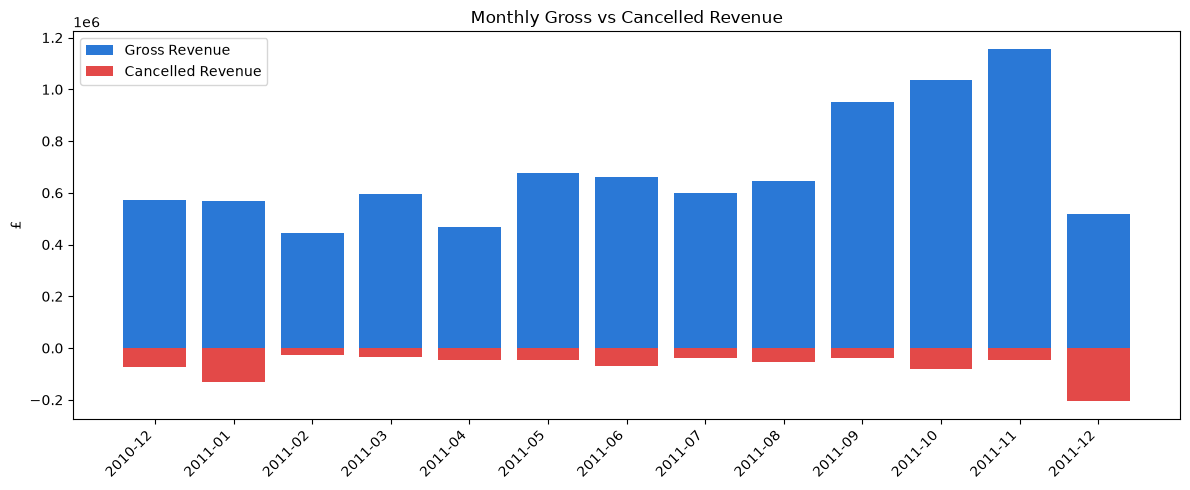

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
x_labels = [f"{y}-{m:02d}" for y,m in zip(q1['Year'], q1['Month'])]
plt.bar(x_labels, q1['GrossRevenue'], color='#2a78d6', label='Gross Revenue')
plt.bar(x_labels, q1['CancelledRevenue'], color='#e34948', label='Cancelled Revenue')
plt.xticks(rotation=45, ha='right')
plt.ylabel('£')
plt.title('Monthly Gross vs Cancelled Revenue')
plt.legend()
plt.tight_layout()
plt.savefig("../results/figures/olap_monthly_revenue.png", dpi=150, bbox_inches='tight')
plt.show()